# Análise Exploratória com PCA e MDS - Vendas de uma rede de açougues

Este notebook aplica **PCA** e **MDS** como técnicas de análise exploratória em um dataset multidimensional de vendas de uma rede de açougues.

O dataset utilizado foi o **Sales at a Chain of Butcher Shops**, disponibilizado no Kaggle:  
https://www.kaggle.com/datasets/frrrmin/sales-at-a-chain-of-butcher-shops

Como o arquivo disponibilizado para a atividade foi criado com dados propositalmente poluídos, a análise considera uma etapa de limpeza antes da aplicação dos métodos. Serão removidos valores ausentes, datas inválidas, textos indevidos em colunas numéricas, valores negativos e outliers extremos.

## 1. Problema investigado

O objetivo do projeto é compreender padrões de venda entre produtos e lojas de uma rede de açougues. A análise busca responder perguntas como:

- Existem produtos ou lojas com comportamento de venda parecido?
- Há produtos com desempenho comercial superior?
- Existem registros agregados que se comportam como outliers?
- A redução para duas dimensões permite visualizar tendências relevantes?

Para isso, os registros foram agregados por **Produto** e **Loja**. Assim, cada ponto nos gráficos representa o desempenho de um produto em uma loja específica.

## 2. Explicação teórica do PCA

O **PCA** (*Principal Component Analysis* ou Análise de Componentes Principais) é uma técnica de redução de dimensionalidade que transforma variáveis originais possivelmente correlacionadas em novos eixos chamados **componentes principais**.

Esses componentes são combinações lineares das variáveis originais e são ordenados pela quantidade de variância explicada. O primeiro componente principal explica a maior parte possível da variabilidade dos dados; o segundo explica a maior parte da variabilidade restante, e assim por diante.

Neste trabalho, o PCA será usado para:

- projetar os dados em 2 dimensões;
- verificar se existem agrupamentos, tendências ou outliers;
- identificar quais variáveis mais influenciam os primeiros componentes;
- discutir se o PCA poderia ser usado para reduzir features em modelos futuros.

## 3. Explicação teórica do MDS

O **MDS** (*Multidimensional Scaling* ou Escalonamento Multidimensional) é uma técnica usada para representar dados em poucas dimensões tentando preservar as distâncias ou dissimilaridades entre os registros.

Diferente do PCA, que cria componentes a partir da variância das variáveis, o MDS foca em manter registros parecidos próximos no gráfico e registros diferentes afastados.

Neste trabalho, o MDS será usado principalmente para visualização, ajudando a verificar se os produtos e lojas com comportamento semelhante aparecem próximos no espaço bidimensional.

In [ ]:
# Importação das bibliotecas
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

In [ ]:
# Carregamento do dataset
arquivo = 'ventas_carniceria_sucio_4000.csv'
df_original = pd.read_csv(arquivo)

print('Dimensões originais:', df_original.shape)
df_original.head()

Dimensões originais: (4120, 6)


,fecha,tienda,producto,precio,cantidad,total_venta
0,2025-11-25,Carniceria Norte,Res,174.84,11.0,1923.24
1,2025-05-27,Cortes Finos MX,NaN,143.09,19.0,2718.71
2,2025-12-23,La Vaca Feliz,Pollo,634.4399999999999,3.0,1903.32
3,2026-03-03,Super Carnes,Res,NaN,564.0,72975.96
4,2025-11-01,El Torito,Res,151.11,10.0,NaN


In [ ]:
# Estrutura inicial do dataset
print('Tipos originais:')
print(df_original.dtypes)

print('\nValores ausentes por coluna:')
print(df_original.isna().sum())

print('\nAmostra aleatória dos dados brutos:')
df_original.sample(5, random_state=42)

Tipos originais:
fecha           object
tienda          object
producto        object
precio          object
cantidad        object
total_venta    float64
dtype: object

Valores ausentes por coluna:
fecha          122
tienda         123
producto       123
precio         120
cantidad       128
total_venta    123
dtype: int64

Amostra aleatória dos dados brutos:


,fecha,tienda,producto,precio,cantidad,total_venta
680,2026-04-15,El Torito,Chorizo,264.45,6.0,1586.70
2836,2026-03-13,El Torito,Costilla,149.92,15.0,2248.80
1042,2025-05-04,La Vaca Feliz,Costilla,NaN,13.0,NaN
3813,2025-07-21,Super Carnes,Arrachera,211.26,6.0,1267.56
1186,2025-12-29,Carniceria Norte,Res,105.36,17.0,1791.12


## 4. Preparação e limpeza dos dados

O dataset já vem propositalmente poluído. Por isso, a limpeza foi tratada como parte importante da análise. Foram realizados os seguintes passos:

1. Renomeação das colunas para facilitar a leitura.
2. Conversão da coluna de data para formato `datetime`.
3. Conversão das colunas numéricas para valores numéricos reais.
4. Remoção de valores ausentes e inválidos.
5. Remoção de valores negativos em preço, quantidade e venda total.
6. Remoção de outliers extremos pelo método do intervalo interquartil (IQR).

Essa etapa evita que erros artificiais do dataset distorçam o PCA e o MDS.

In [ ]:
# Renomeação das colunas
df = df_original.rename(columns={
    'fecha': 'Data',
    'tienda': 'Loja',
    'producto': 'Produto',
    'precio': 'Preco',
    'cantidad': 'Quantidade',
    'total_venta': 'Venda_Total'
}).copy()

# Padronização de strings
for col in ['Loja', 'Produto']:
    df[col] = df[col].astype('string').str.strip()

# Conversão de tipos
for col in ['Preco', 'Quantidade', 'Venda_Total']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Data'] = pd.to_datetime(df['Data'], errors='coerce', format='mixed')

resumo_limpeza = []
resumo_limpeza.append(['Registros originais', len(df)])

# Remoção de ausentes/invalidos nas colunas essenciais
df_limpo = df.dropna(subset=['Data', 'Loja', 'Produto', 'Preco', 'Quantidade', 'Venda_Total']).copy()
resumo_limpeza.append(['Após remover ausentes e conversões inválidas', len(df_limpo)])

# Remoção de valores negativos ou zerados nas variáveis numéricas principais
df_limpo = df_limpo[(df_limpo['Preco'] > 0) & (df_limpo['Quantidade'] > 0) & (df_limpo['Venda_Total'] > 0)].copy()
resumo_limpeza.append(['Após remover valores negativos/zerados', len(df_limpo)])

# Remoção preventiva de categorias desconhecidas, caso existam
mascara_desconhecido = df_limpo['Produto'].str.lower().isin(['desconhecido', 'unknown', 'nan'])
df_limpo = df_limpo[~mascara_desconhecido].copy()
resumo_limpeza.append(['Após remover produtos desconhecidos, caso existam', len(df_limpo)])

# Remoção de outliers extremos via IQR nas variáveis numéricas originais
def limites_iqr(serie, fator=1.5):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - fator * iqr, q3 + fator * iqr

mascara = pd.Series(True, index=df_limpo.index)
limites = {}
for col in ['Preco', 'Quantidade', 'Venda_Total']:
    lim_inf, lim_sup = limites_iqr(df_limpo[col])
    limites[col] = (lim_inf, lim_sup)
    mascara &= df_limpo[col].between(lim_inf, lim_sup)

df_limpo = df_limpo[mascara].copy()
resumo_limpeza.append(['Após remover outliers extremos por IQR', len(df_limpo)])

resumo_limpeza_df = pd.DataFrame(resumo_limpeza, columns=['Etapa', 'Quantidade de registros'])
resumo_limpeza_df

,Etapa,Quantidade de registros
0,Registros originais,4120
1,Após remover ausentes e conversões inválidas,3282
2,Após remover valores negativos/zerados,3246
3,"Após remover produtos desconhecidos, caso existam",3246
4,Após remover outliers extremos por IQR,3049


In [ ]:
print('Limites usados no filtro IQR:')
for coluna, (lim_inf, lim_sup) in limites.items():
    print(f'{coluna}: {lim_inf:.2f} até {lim_sup:.2f}')

print('\nDimensão final após limpeza:', df_limpo.shape)
print('\nProdutos após limpeza:')
print(df_limpo['Produto'].value_counts())

print('\nLojas após limpeza:')
print(df_limpo['Loja'].value_counts())

Limites usados no filtro IQR:
Preco: 11.70 até 292.52
Quantidade: -7.50 até 28.50
Venda_Total: -1591.29 até 4623.91

Dimensão final após limpeza: (3049, 6)

Produtos após limpeza:
Produto
Chorizo      535
Costilla     535
Pollo        527
Res          505
Arrachera    479
Cerdo        468
Name: count, dtype: Int64

Lojas após limpeza:
Loja
Super Carnes        642
Cortes Finos MX     616
El Torito           607
Carniceria Norte    597
La Vaca Feliz       587
Name: count, dtype: Int64


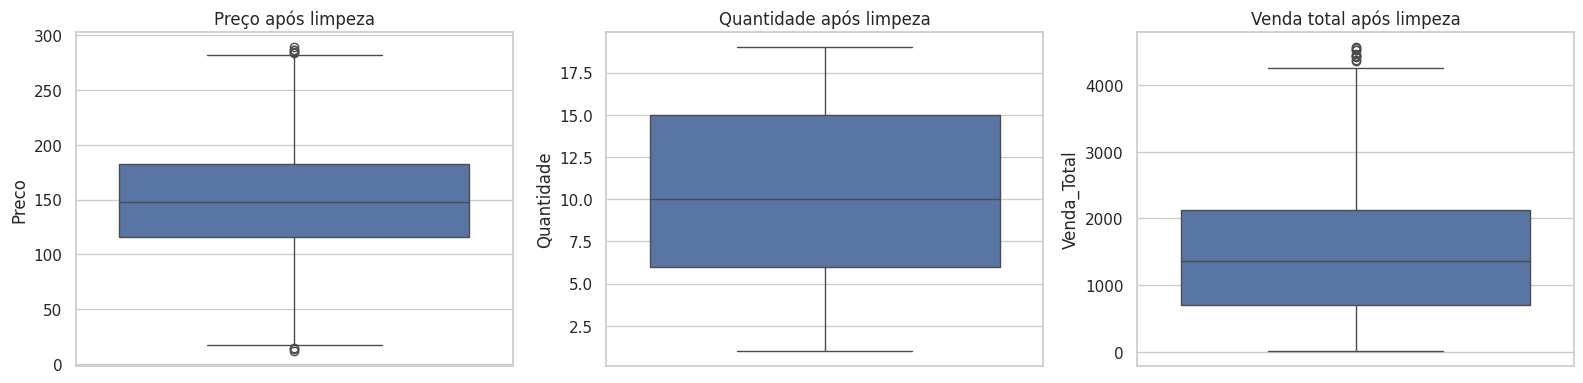

In [ ]:
# Visualização descritiva após a limpeza
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df_limpo, y='Preco', ax=axes[0])
axes[0].set_title('Preço após limpeza')

sns.boxplot(data=df_limpo, y='Quantidade', ax=axes[1])
axes[1].set_title('Quantidade após limpeza')

sns.boxplot(data=df_limpo, y='Venda_Total', ax=axes[2])
axes[2].set_title('Venda total após limpeza')

plt.tight_layout()
plt.show()

## 5. Seleção e justificativa das features

O dataset original possui poucas colunas numéricas diretas. Para tornar a análise multidimensional mais rica, os dados foram agregados por **Produto** e **Loja**. Assim, cada registro final representa o desempenho de um produto em uma loja.

As features selecionadas foram:

- `numero_vendas`: quantidade de vendas registradas para o produto na loja;
- `quantidade_total`: soma das unidades vendidas;
- `preco_medio`: preço médio praticado;
- `preco_std`: variação do preço;
- `receita_total`: soma da receita obtida;
- `ticket_medio`: valor médio de venda;
- `dias_com_venda`: quantidade de dias distintos com venda registrada.

Essas variáveis permitem analisar volume, receita, preço, frequência e variabilidade comercial.

In [ ]:
# Criação da base analítica agregada por Produto e Loja
df_limpo['Mes'] = df_limpo['Data'].dt.month

df_analise = (
    df_limpo
    .groupby(['Produto', 'Loja'])
    .agg(
        numero_vendas=('Venda_Total', 'size'),
        quantidade_total=('Quantidade', 'sum'),
        preco_medio=('Preco', 'mean'),
        preco_std=('Preco', 'std'),
        receita_total=('Venda_Total', 'sum'),
        ticket_medio=('Venda_Total', 'mean'),
        dias_com_venda=('Data', 'nunique')
    )
    .reset_index()
)

df_analise['preco_std'] = df_analise['preco_std'].fillna(0)

features = [
    'numero_vendas',
    'quantidade_total',
    'preco_medio',
    'preco_std',
    'receita_total',
    'ticket_medio',
    'dias_com_venda'
]

print('Dimensão da base analítica:', df_analise.shape)
df_analise.head()

Dimensão da base analítica: (30, 9)


,Produto,Loja,numero_vendas,quantidade_total,preco_medio,preco_std,receita_total,ticket_medio,dias_com_venda
0,Arrachera,Carniceria Norte,89,926.0,148.732022,47.698689,137699.05,1547.180337,75
1,Arrachera,Cortes Finos MX,92,932.0,148.126522,55.855980,141166.29,1534.416196,81
2,Arrachera,El Torito,106,1063.0,147.984623,47.447355,163010.38,1537.833774,87
3,Arrachera,La Vaca Feliz,94,933.0,149.493298,48.710051,140297.10,1492.522340,81
4,Arrachera,Super Carnes,98,1054.0,146.295408,48.150027,157544.08,1607.592653,85


In [ ]:
# Estatísticas da base analítica
round(df_analise[features].describe(), 2)

,numero_vendas,quantidade_total,preco_medio,preco_std,receita_total,ticket_medio,dias_com_venda
count,30.00,30.00,30.00,30.00,30.00,30.00,30.00
mean,101.63,1029.43,148.52,48.89,152252.95,1498.93,86.17
std,10.64,118.15,4.19,4.04,18304.13,100.57,7.73
min,78.00,816.00,138.60,41.95,118089.25,1279.33,67.00
25%,94.00,934.50,146.38,46.11,139693.43,1414.74,81.25
50%,101.50,1019.50,148.43,48.23,150283.02,1514.59,85.50
75%,108.75,1117.00,151.20,52.16,162912.44,1559.53,90.75
max,123.00,1235.00,156.82,56.76,187183.94,1693.71,102.00


## 6. Padronização dos dados

Como as features possuem escalas diferentes, por exemplo receita total em valores monetários e número de vendas em contagens, foi aplicada padronização com `StandardScaler`.

A padronização deixa cada variável com média próxima de 0 e desvio padrão próximo de 1, evitando que variáveis de maior escala dominem o PCA e o MDS.

In [ ]:
# Padronização das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_analise[features])

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
round(X_scaled_df.describe(), 2)

,numero_vendas,quantidade_total,preco_medio,preco_std,receita_total,ticket_medio,dias_com_venda
count,30.00,30.00,30.00,30.00,30.00,30.00,30.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,1.02
min,-2.26,-1.84,-2.41,-1.75,-1.90,-2.22,-2.52
25%,-0.73,-0.82,-0.52,-0.70,-0.70,-0.85,-0.65
50%,-0.01,-0.09,-0.02,-0.17,-0.11,0.16,-0.09
75%,0.68,0.75,0.65,0.83,0.59,0.61,0.60
max,2.04,1.77,2.01,1.98,1.94,1.97,2.08


## 7. Aplicação do PCA

A seguir, aplicamos o PCA sobre os dados padronizados. O objetivo é projetar os registros em duas dimensões e analisar a variância explicada pelos componentes principais.

In [ ]:
# Aplicação do PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

variancia = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Variancia explicada': pca.explained_variance_ratio_,
    'Variancia acumulada': np.cumsum(pca.explained_variance_ratio_)
})

round(variancia, 4)

,Componente,Variancia explicada,Variancia acumulada
0,PC1,0.5283,0.5283
1,PC2,0.2456,0.7739
2,PC3,0.1136,0.8875
3,PC4,0.0976,0.9851
4,PC5,0.0132,0.9983
5,PC6,0.0016,0.9998
6,PC7,0.0002,1.0000


In [ ]:
print(f"PC1 explicou: {pca.explained_variance_ratio_[0] * 100:.2f}% da variância.")
print(f"PC2 explicou: {pca.explained_variance_ratio_[1] * 100:.2f}% da variância.")
print(f"Juntos, PC1 e PC2 explicaram: {pca.explained_variance_ratio_[:2].sum() * 100:.2f}% da variância.")
print(f"Com 3 componentes, a variância acumulada chega a: {pca.explained_variance_ratio_[:3].sum() * 100:.2f}%.")

PC1 explicou: 52.83% da variância.
PC2 explicou: 24.56% da variância.
Juntos, PC1 e PC2 explicaram: 77.39% da variância.
Com 3 componentes, a variância acumulada chega a: 88.75%.


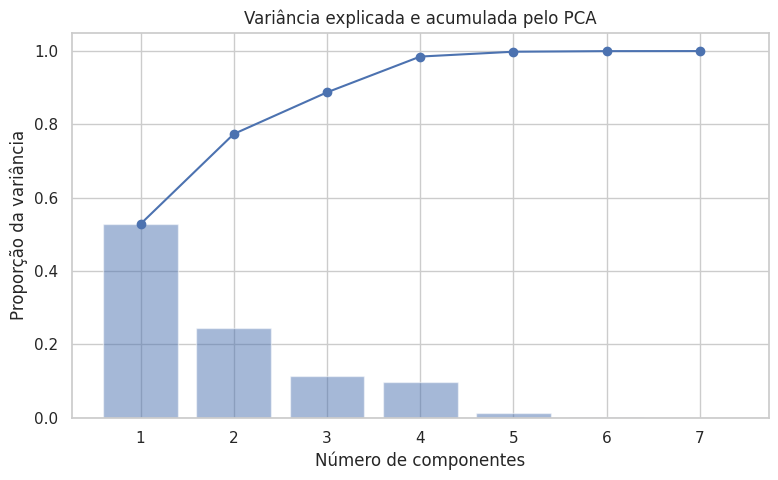

In [ ]:
# Gráfico da variância explicada
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.5)
plt.xlabel('Número de componentes')
plt.ylabel('Proporção da variância')
plt.title('Variância explicada e acumulada pelo PCA')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.ylim(0, 1.05)
plt.show()

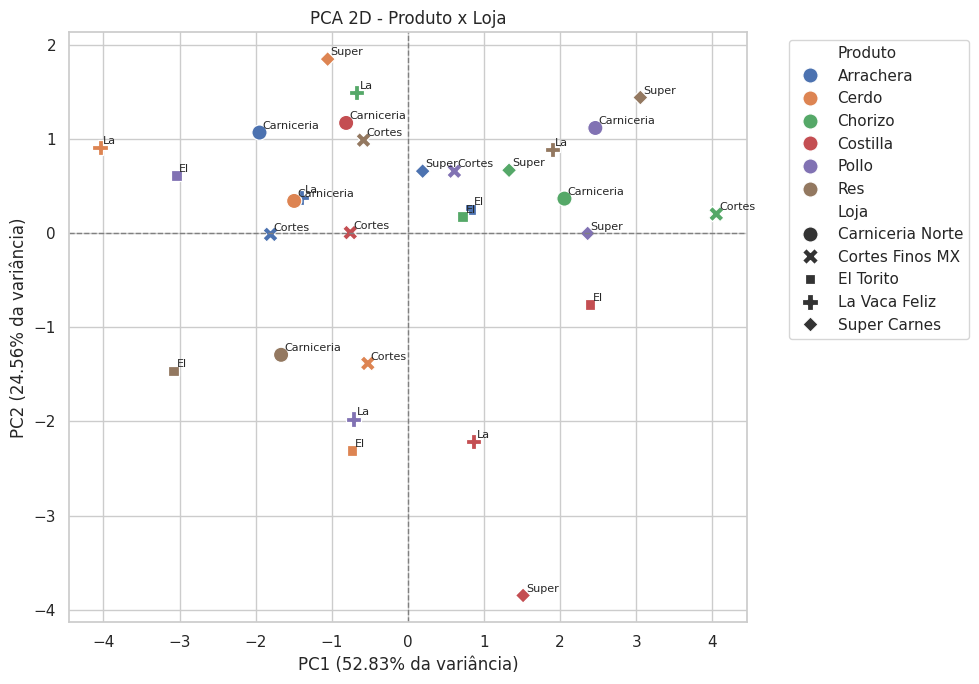

In [ ]:
# DataFrame com os dois primeiros componentes
pca_df = df_analise[['Produto', 'Loja']].copy()
pca_df['PC1'] = X_pca[:, 0]
pca_df['PC2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Produto', style='Loja', s=120)

for _, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.04, row['PC2'] + 0.04, row['Loja'].split()[0], fontsize=8)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('PCA 2D - Produto x Loja')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% da variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% da variância)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Contribuição das variáveis no PCA

Os *loadings* mostram quanto cada variável contribui para os componentes principais. Valores absolutos maiores indicam maior influência no componente.

In [ ]:
# Loadings dos dois primeiros componentes
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=features,
    columns=['PC1', 'PC2']
)

round(loadings, 4)

,PC1,PC2
numero_vendas,0.4835,-0.2453
quantidade_total,0.5050,0.0189
preco_medio,0.0350,0.5446
preco_std,-0.2139,-0.3012
receita_total,0.5018,0.1590
ticket_medio,0.1402,0.6465
dias_com_venda,0.4390,-0.3300


In [ ]:
# Ranking de influência por componente
ranking_pc1 = loadings['PC1'].abs().sort_values(ascending=False)
ranking_pc2 = loadings['PC2'].abs().sort_values(ascending=False)

print('Variáveis que mais influenciaram o PC1:')
print(ranking_pc1)

print('\nVariáveis que mais influenciaram o PC2:')
print(ranking_pc2)

Variáveis que mais influenciaram o PC1:
quantidade_total    0.505033
receita_total       0.501837
numero_vendas       0.483455
dias_com_venda      0.439015
preco_std           0.213903
ticket_medio        0.140212
preco_medio         0.034996
Name: PC1, dtype: float64

Variáveis que mais influenciaram o PC2:
ticket_medio        0.646517
preco_medio         0.544552
dias_com_venda      0.330039
preco_std           0.301218
numero_vendas       0.245306
receita_total       0.159024
quantidade_total    0.018897
Name: PC2, dtype: float64


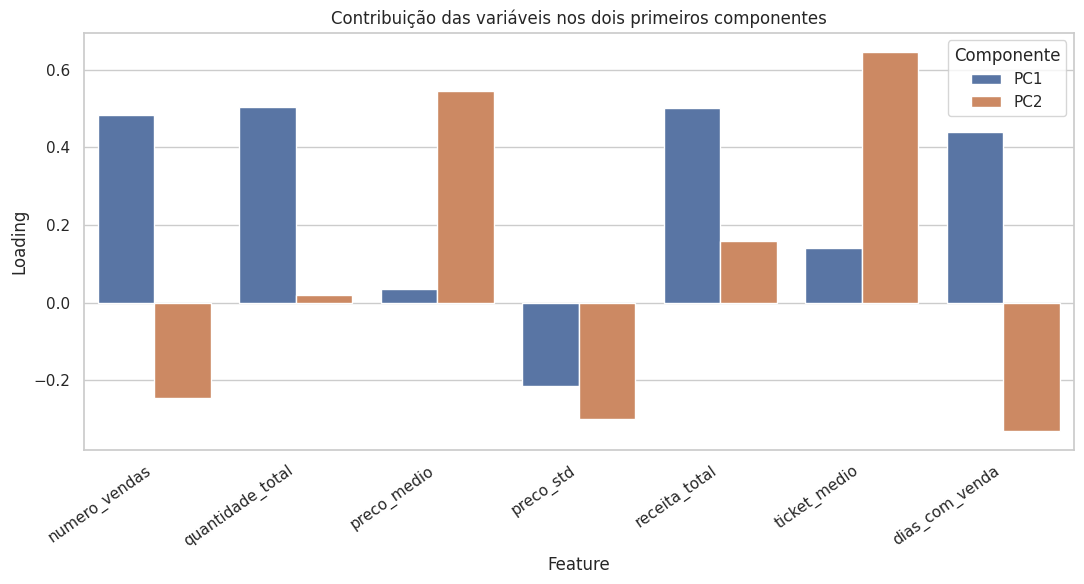

In [ ]:
# Gráfico dos loadings
loadings_plot = loadings.reset_index().melt(id_vars='index', var_name='Componente', value_name='Loading')
loadings_plot = loadings_plot.rename(columns={'index': 'Feature'})

plt.figure(figsize=(11, 6))
sns.barplot(data=loadings_plot, x='Feature', y='Loading', hue='Componente')
plt.xticks(rotation=35, ha='right')
plt.title('Contribuição das variáveis nos dois primeiros componentes')
plt.tight_layout()
plt.show()

### Interpretação do PCA

O **PC1** foi mais influenciado por `quantidade_total`, `receita_total`, `numero_vendas` e `dias_com_venda`. Portanto, esse eixo representa principalmente o **volume e desempenho comercial** dos produtos nas lojas.

O **PC2** foi mais influenciado por `ticket_medio` e `preco_medio`. Assim, esse eixo representa principalmente o **nível de preço e valor médio das vendas**.

Como PC1 e PC2 juntos explicam cerca de 77% da variância, a visualização em duas dimensões é adequada para análise exploratória. Ainda assim, o terceiro componente adiciona informação relevante e poderia ser considerado em uma análise mais completa.

## 9. Aplicação do MDS

O MDS foi aplicado sobre os dados padronizados com distância euclidiana. A ideia é verificar se registros com perfis parecidos de venda ficam próximos no gráfico bidimensional.

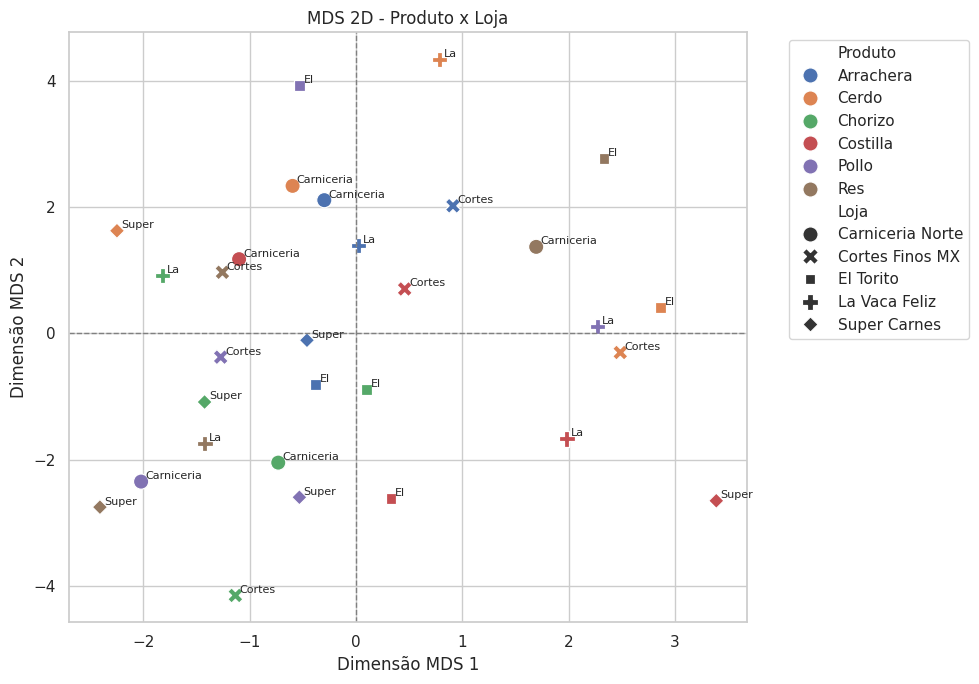

Stress do MDS: 149.7616


In [ ]:
# Aplicação do MDS
mds = MDS(
    n_components=2,
    metric='euclidean',
    metric_mds=True,
    init='random',
    n_init=10,
    max_iter=1000,
    random_state=42,
    normalized_stress='auto'
)

X_mds = mds.fit_transform(X_scaled)

mds_df = df_analise[['Produto', 'Loja']].copy()
mds_df['MDS1'] = X_mds[:, 0]
mds_df['MDS2'] = X_mds[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=mds_df, x='MDS1', y='MDS2', hue='Produto', style='Loja', s=120)

for _, row in mds_df.iterrows():
    plt.text(row['MDS1'] + 0.04, row['MDS2'] + 0.04, row['Loja'].split()[0], fontsize=8)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('MDS 2D - Produto x Loja')
plt.xlabel('Dimensão MDS 1')
plt.ylabel('Dimensão MDS 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f'Stress do MDS: {mds.stress_:.4f}')

In [ ]:
# Comparação da preservação das distâncias
# Quanto maior a correlação de Spearman, melhor a projeção preserva a ordem das distâncias originais.
dist_original = pdist(X_scaled)
dist_pca_2d = pdist(X_pca[:, :2])
dist_mds_2d = pdist(X_mds)

corr_pca = spearmanr(dist_original, dist_pca_2d).statistic
corr_mds = spearmanr(dist_original, dist_mds_2d).statistic

print(f'Correlação das distâncias originais com PCA 2D: {corr_pca:.4f}')
print(f'Correlação das distâncias originais com MDS 2D: {corr_mds:.4f}')

Correlação das distâncias originais com PCA 2D: 0.9315
Correlação das distâncias originais com MDS 2D: 0.9347


### Interpretação do MDS

O MDS apresentou uma organização visual parecida com o PCA, preservando bem as relações de proximidade entre os registros. Produtos e lojas com perfis semelhantes de volume, receita e ticket médio aparecem próximos no gráfico.

A correlação entre as distâncias originais e as distâncias no MDS 2D ficou alta, indicando que a projeção bidimensional representa bem as similaridades gerais da base analítica. Isso reforça que o MDS é útil para visualização exploratória neste problema.

## 10. Identificação de padrões e outliers

Para identificar pontos mais afastados no PCA, foi calculada a distância de cada registro ao centro do gráfico formado por PC1 e PC2. Os maiores valores indicam possíveis outliers ou combinações Produto-Loja com comportamento mais diferente dos demais.

In [ ]:
# Identificação de possíveis outliers na projeção PCA
resultado = df_analise.copy()
resultado['PC1'] = X_pca[:, 0]
resultado['PC2'] = X_pca[:, 1]
resultado['MDS1'] = X_mds[:, 0]
resultado['MDS2'] = X_mds[:, 1]
resultado['distancia_pca'] = np.sqrt((resultado['PC1'] - resultado['PC1'].mean())**2 + (resultado['PC2'] - resultado['PC2'].mean())**2)

possiveis_outliers = resultado.sort_values('distancia_pca', ascending=False).head(6)
possiveis_outliers[['Produto', 'Loja', 'distancia_pca', 'receita_total', 'ticket_medio', 'quantidade_total', 'numero_vendas', 'preco_medio', 'preco_std']]

,Produto,Loja,distancia_pca,receita_total,ticket_medio,quantidade_total,numero_vendas,preco_medio,preco_std
8,Cerdo,La Vaca Feliz,4.145256,118089.25,1513.964744,816.0,78,146.356795,48.294828
19,Costilla,Super Carnes,4.135866,155987.87,1310.822437,1144.0,119,138.600672,54.105049
11,Chorizo,Cortes Finos MX,4.057255,186887.87,1519.413577,1227.0,123,152.698374,44.040599
27,Res,El Torito,3.408668,122188.66,1372.906292,860.0,89,146.469101,56.760240
29,Res,Super Carnes,3.377772,187183.94,1671.285179,1235.0,112,151.979732,48.156599
22,Pollo,El Torito,3.104592,127391.60,1431.366292,830.0,89,156.822247,55.284695


In [ ]:
# Médias por produto para apoiar a interpretação
medias_produto = resultado.groupby('Produto')[features].mean().sort_values('receita_total', ascending=False)
round(medias_produto, 2)

,numero_vendas,quantidade_total,preco_medio,preco_std,receita_total,ticket_medio,dias_com_venda
Produto,,,,,,,
Chorizo,107.0,1115.2,149.75,46.33,166528.73,1559.37,90.4
Pollo,105.4,1049.0,151.08,49.38,155883.22,1475.06,86.4
Costilla,107.0,1064.6,145.54,50.17,154844.88,1453.53,91.8
Res,101.0,1030.0,148.82,49.41,153069.17,1506.27,85.2
Arrachera,95.8,981.6,148.13,49.57,147943.38,1543.91,81.8
Cerdo,93.6,936.2,147.78,48.45,135248.34,1455.46,81.4


### Descobertas principais

- O produto **Chorizo** apresentou, em média, maior receita total, maior quantidade total vendida e maior número de vendas entre os produtos analisados.
- **Cerdo** teve menor receita média agregada e menor volume médio, ficando mais afastado dos produtos de melhor desempenho.
- O **PC1** separou principalmente registros com maior ou menor volume comercial.
- O **PC2** separou registros por diferenças relacionadas a preço médio e ticket médio.
- Alguns pontos mais distantes representam combinações específicas de produto e loja que se destacam por volume, preço ou variabilidade maior do que os demais.
- PCA e MDS mostraram padrões semelhantes, indicando que a estrutura de proximidade observada nos dados é relativamente consistente.

## 11. Comparação entre PCA e MDS

O PCA e o MDS tiveram papéis complementares:

- O **PCA** foi melhor para entender quais variáveis explicam a separação dos registros, pois fornece variância explicada e loadings.
- O **MDS** foi melhor para confirmar visualmente a proximidade entre registros semelhantes, pois tenta preservar as distâncias entre eles.
- Ambos indicaram que volume de venda, receita e ticket médio são fatores importantes para diferenciar os registros agregados.
- Os padrões visuais foram parecidos, mas o PCA é mais indicado para redução de features, enquanto o MDS é mais indicado para visualização exploratória de similaridades.

## 12. Respostas às perguntas roteadoras

**Qual é o problema investigado no projeto?**  
Investigar padrões de venda em uma rede de açougues, analisando produtos e lojas com base em volume, receita, preço e frequência de vendas.

**Quais features foram selecionadas?**  
`numero_vendas`, `quantidade_total`, `preco_medio`, `preco_std`, `receita_total`, `ticket_medio` e `dias_com_venda`.

**Que padrões vocês esperavam encontrar antes da análise?**  
Esperávamos que produtos com maior volume de venda e maior receita ficassem mais próximos entre si, enquanto produtos com preços ou tickets médios diferentes pudessem se separar visualmente.

**O PCA revelou agrupamentos, tendências ou outliers?**  
Sim. O PCA revelou uma tendência de separação por desempenho comercial e apontou possíveis registros mais distantes, associados a combinações Produto-Loja com comportamento diferente.

**Quais variáveis mais influenciaram os primeiros componentes principais?**  
No PC1, as mais influentes foram `quantidade_total`, `receita_total`, `numero_vendas` e `dias_com_venda`. No PC2, foram `ticket_medio` e `preco_medio`.

**A variância explicada pelos dois primeiros componentes foi suficiente para uma boa visualização?**  
Sim. Os dois primeiros componentes explicaram cerca de 77% da variância, o que é adequado para visualização exploratória.

**O MDS revelou registros semelhantes ou grupos de registros?**  
Sim. O MDS aproximou registros com comportamento semelhante de venda, principalmente em relação a volume, receita e ticket médio.

**Os padrões do MDS foram parecidos com os padrões do PCA?**  
Sim. As duas técnicas mostraram uma estrutura visual parecida, com boa preservação das relações de proximidade.

**Alguma categoria ficou visualmente separada no gráfico?**  
Alguns produtos, como Chorizo e Cerdo, apresentaram tendências distintas em termos médios: Chorizo mais associado a maior desempenho comercial e Cerdo a menor volume/receita.

**Foram encontrados outliers? O que explica esses outliers nos dados originais?**  
Foram encontrados pontos mais distantes na projeção, explicados por combinações específicas de produto e loja com maior volume, maior ticket ou maior variação de preço. Outliers extremos artificiais do dataset foram removidos na limpeza.

**Os padrões observados fazem sentido no contexto do projeto?**  
Sim. Em uma rede de açougues, é esperado que produtos diferentes apresentem comportamentos distintos de demanda, receita e preço médio.

**Existe algum risco de interpretar incorretamente os gráficos?**  
Sim. Os gráficos são projeções 2D e podem esconder parte da informação original. Além disso, proximidade visual não significa causalidade.

**O PCA poderia ser usado para reduzir features em um modelo?**  
Sim. Como os primeiros componentes acumulam boa parte da variância, o PCA poderia reduzir as features, especialmente usando dois ou três componentes.

**O MDS seria mais adequado para visualização ou para redução de features?**  
O MDS é mais adequado para visualização de similaridades. Para redução de features em modelos, o PCA é mais apropriado.

**O que foi aprendido sobre o dataset após aplicar os dois métodos?**  
Aprendemos que o desempenho dos produtos varia principalmente por volume de vendas, receita e ticket médio. Também ficou claro que a limpeza dos dados é essencial, pois o dataset possui erros intencionais que poderiam distorcer a análise.

## 13. Conclusão

A aplicação de PCA e MDS ajudou a compreender melhor o dataset de vendas da rede de açougues. Após a limpeza dos dados, foi possível construir uma base analítica com múltiplas variáveis numéricas e visualizar diferenças entre produtos e lojas.

O PCA mostrou que a principal dimensão dos dados está relacionada ao desempenho comercial, especialmente quantidade vendida, receita total, número de vendas e dias com venda. Já o segundo componente está mais ligado a preço médio e ticket médio.

O MDS confirmou visualmente relações semelhantes de proximidade entre os registros, funcionando como uma técnica complementar de visualização. Assim, os métodos permitiram identificar tendências, possíveis outliers e diferenças relevantes entre os produtos analisados.